# Notebook 05 — Hypothesis B: Calinski–Harabasz and sample size

**Issue:** With an **expanding** train window, $n$ grows. CH = $\frac{SS_B/(k-1)}{SS_W/(n-k)}$ tends to rise as the denominator **shrinks** if $SS_W$ does not grow as fast—so part of the upward drift can be **mechanical**.

**Test:** For each refit, compare CH from the **paper 11-year expanding** window vs CH from a **rolling fixed-length** window (last `FIXED_TRAIN_DAYS` trading days), same $\lambda$. Regress CH on $n$ for both designs; compare Slopes / correlations.

**Fast mode:** set env `THESIS_FAST_NOTEBOOKS=1` to fit only **LargeCap, EAFE, AggBond** (saves time in Docker).


In [1]:
import os
import sys
import pickle
import warnings
from pathlib import Path

_here = Path.cwd().resolve()
_repo_root = _here
for _ in range(16):
    if (_repo_root / "src" / "config" / "settings.py").is_file():
        break
    if _repo_root.parent == _repo_root:
        raise RuntimeError("Cannot find repo root")
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils.helpers import setup_logging
setup_logging()

RESULTS_DIR = _repo_root / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

from src.config.settings import (
    ASSETS, ASSET_TICKERS, FRED_SERIES,
    DATA_START, DATA_END, TEST_START, TEST_END,
    TRAIN_YEARS, REBAL_MONTHS,
)
from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.features.return_features import ReturnFeatureBuilder
from src.models.regime_framework import _rebalance_dates
from src.models.jump_model import JumpModel
from src.cluster_stability import internal_validity_scores
from src.analysis.time_series_stats import hac_ols

FAST = os.environ.get("THESIS_FAST_NOTEBOOKS", "").lower() in ("1", "true", "yes")
ASSET_LOOP = ["LargeCap", "EAFE", "AggBond"] if FAST else list(ASSETS)
FIXED_LAMBDA = 10.0
FIXED_TRAIN_DAYS = 252 * 5  # ~5y trading days

loader = DataLoader()
prices = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
fred = loader.load_fred(FRED_SERIES, start=DATA_START, end=DATA_END)
prep = DataPreprocessor()
excess_returns, _, _ = prep.prepare(prices, fred)
idx = excess_returns.index
ret_feat = ReturnFeatureBuilder()
rebal_dates = _rebalance_dates(idx, TEST_START, TEST_END, tuple(REBAL_MONTHS))
print("FAST", FAST, "assets", ASSET_LOOP, "refits", len(rebal_dates))


2026-04-27 18:10:29 | INFO     | src.data.loader | Loading prices from cache: /home/researcher/app/data/raw/prices_1991-01-01_2023-12-31.pkl
2026-04-27 18:10:29 | INFO     | src.data.loader | Loading FRED data from cache: /home/researcher/app/data/raw/fred_1991-01-01_2023-12-31.pkl
2026-04-27 18:10:29 | INFO     | src.data.preprocessor | event=preprocess_step step=input_prices rows=5941 cols=12 start=2000-05-19 end=2023-12-29 na_count=10714
2026-04-27 18:10:29 | INFO     | src.data.preprocessor | event=preprocess_step step=input_fred rows=8608 cols=5 start=1991-01-02 end=2023-12-29 na_count=8582
2026-04-27 18:10:29 | INFO     | src.data.preprocessor | event=preprocess_step step=simple_returns rows=5941 cols=12 start=2000-05-19 end=2023-12-29 na_count=10726
2026-04-27 18:10:29 | INFO     | src.data.preprocessor | event=preprocess_step step=fred_aligned rows=5941 cols=5 start=2000-05-19 end=2023-12-29 na_count=0
2026-04-27 18:10:29 | INFO     | src.data.preprocessor | event=preprocess_st

FAST False assets ['LargeCap', 'MidCap', 'SmallCap', 'EAFE', 'EM', 'AggBond', 'Treasury', 'HighYield', 'Corporate', 'REIT', 'Commodity', 'Gold'] refits 34


In [2]:
rows = []
for asset in ASSET_LOOP:
    X_full = ret_feat.build(excess_returns[asset], asset, for_jm=True)
    er_a = excess_returns[asset]
    for rebal_date in rebal_dates:
        train_start = rebal_date - pd.DateOffset(years=TRAIN_YEARS)
        train_idx = idx[(idx >= train_start) & (idx < rebal_date)]
        if len(train_idx) < 252:
            continue
        X_exp = X_full.reindex(train_idx).dropna()
        if len(X_exp) < 100:
            continue
        tail_idx = X_exp.index[-FIXED_TRAIN_DAYS:]
        if len(tail_idx) < 100:
            continue
        X_fixed_win = X_exp.reindex(tail_idx).dropna()
        if len(X_fixed_win) < 100:
            continue

        jm_e = JumpModel(jump_pen=FIXED_LAMBDA)
        jm_e.fit(X_exp.values)
        er_train = er_a.reindex(X_exp.index)
        stats_e = jm_e.regime_stats(er_train.values)
        bull_e = max(stats_e, key=lambda k: stats_e[k]["mean_daily"])
        labels_e = (jm_e.labels_ != bull_e).astype(int)
        ch_e = internal_validity_scores(X_exp.values, labels_e)["calinski_harabasz"]

        jm_f = JumpModel(jump_pen=FIXED_LAMBDA)
        jm_f.fit(X_fixed_win.values)
        er_f = er_a.reindex(X_fixed_win.index)
        stats_f = jm_f.regime_stats(er_f.values)
        bull_f = max(stats_f, key=lambda k: stats_f[k]["mean_daily"])
        labels_f = (jm_f.labels_ != bull_f).astype(int)
        ch_f = internal_validity_scores(X_fixed_win.values, labels_f)["calinski_harabasz"]

        rows.append(
            {
                "Asset": asset,
                "Rebal_date": rebal_date,
                "n_expanding": int(len(X_exp)),
                "n_fixed_window": int(len(X_fixed_win)),
                "ch_expanding": ch_e,
                "ch_fixed": ch_f,
            }
        )

ch_df = pd.DataFrame(rows)
ch_df.to_csv(RESULTS_DIR / "hypothesis_B_ch_expanding_vs_fixed.csv", index=False)
print(ch_df.head())
print("saved", len(ch_df), "rows")


      Asset Rebal_date  n_expanding  n_fixed_window  ch_expanding     ch_fixed
0  LargeCap 2007-01-03         1643            1260   1214.784995   897.719184
1  LargeCap 2007-07-02         1767            1260   1325.642094   851.163598
2  LargeCap 2008-01-02         1894            1260   1452.997486  1033.301347
3  LargeCap 2008-07-01         2019            1260   1569.648762  1104.562925
4  LargeCap 2009-01-02         2147            1260   1658.290283   989.936837
saved 408 rows


In [3]:
# Slopes: CH ~ n for expanding vs fixed (pool or by asset)
summ = []
for asset in ASSET_LOOP:
    sub = ch_df[ch_df["Asset"] == asset].dropna(subset=["ch_expanding", "n_expanding"])
    if len(sub) < 8:
        continue
    r_e = hac_ols(sub["ch_expanding"].values, sub["n_expanding"].values)
    r_f = hac_ols(sub["ch_fixed"].values, sub["n_fixed_window"].values)
    summ.append(
        {
            "Asset": asset,
            "slope_CH_on_n_expanding": r_e.params[1],
            "p_expanding": r_e.pvalues[1],
            "slope_CH_on_n_fixed": r_f.params[1],
            "p_fixed": r_f.pvalues[1],
        }
    )
slope_tbl = pd.DataFrame(summ)
slope_tbl.to_csv(RESULTS_DIR / "hypothesis_B_ch_regression_slopes.csv", index=False)
print(slope_tbl.to_string(index=False))


    Asset  slope_CH_on_n_expanding  p_expanding  slope_CH_on_n_fixed       p_fixed
 LargeCap                 0.570246 1.638915e-27             0.749657 5.917832e-233
   MidCap                 0.052925 5.255919e-01             0.575853  1.350475e-28
 SmallCap                -0.095960 4.314926e-01             0.634224 1.315717e-100
     EAFE                 1.233697 3.694517e-05             0.834652  2.130893e-43
       EM                 0.706734 1.732348e-06             0.753390  1.107707e-33
  AggBond                 0.857841 3.830417e-05             0.612550  9.325693e-34
 Treasury                -1.653078 1.045837e-01             1.018501  4.851712e-24
HighYield                 0.497751 2.024838e-02             0.562499  4.590255e-16
Corporate              -224.142567 1.011553e-09             0.688754  1.520615e-33
     REIT                -0.202503 4.093053e-01             0.711136  5.262127e-25
Commodity                 0.687044 1.649737e-01             0.910353  1.049245e-30
    

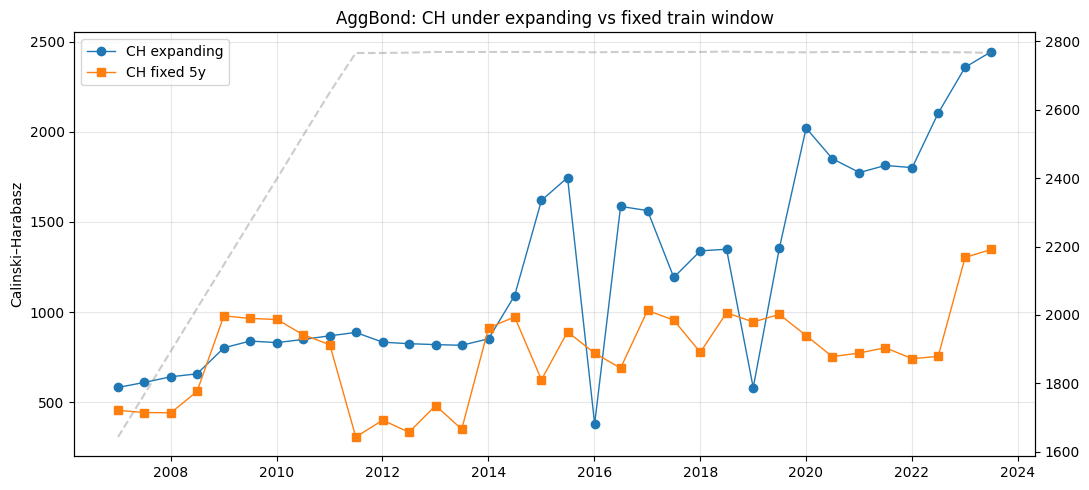

In [4]:
asset_plot = "AggBond" if "AggBond" in ch_df["Asset"].values else ch_df["Asset"].iloc[0]
sub = ch_df[ch_df["Asset"] == asset_plot]
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(sub["Rebal_date"], sub["ch_expanding"], marker="o", label="CH expanding", lw=1)
ax1.plot(sub["Rebal_date"], sub["ch_fixed"], marker="s", label="CH fixed 5y", lw=1)
ax1.set_ylabel("Calinski–Harabasz")
ax2 = ax1.twinx()
ax2.plot(sub["Rebal_date"], sub["n_expanding"], color="gray", alpha=0.4, ls="--", label="n expanding")
ax1.set_title(f"{asset_plot}: CH under expanding vs fixed train window")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "hypothesis_B_ch_expanding_vs_fixed.png", dpi=150)
plt.show()
